### Importing Libraries

In [200]:
import numpy as np
import scipy.signal as signal
import librosa
import matplotlib.pyplot as plt
from IPython.display import display, Audio

## 2 Fuctions for displaying the spectrogram and the audio

In [201]:
def plot_spectrogram(y, sr, title):
    plt.figure(figsize=(12, 4))
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)) + 1e-9, ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', cmap='magma')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title, fontsize=10)
    plt.tight_layout()
    plt.show()
    plt.close()

def save_audio_step(y, sr, step_name):
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y)) * 0.95
    display(Audio(y, rate=sr))
    plot_spectrogram(y, sr, step_name)


# LOAD AUDIO


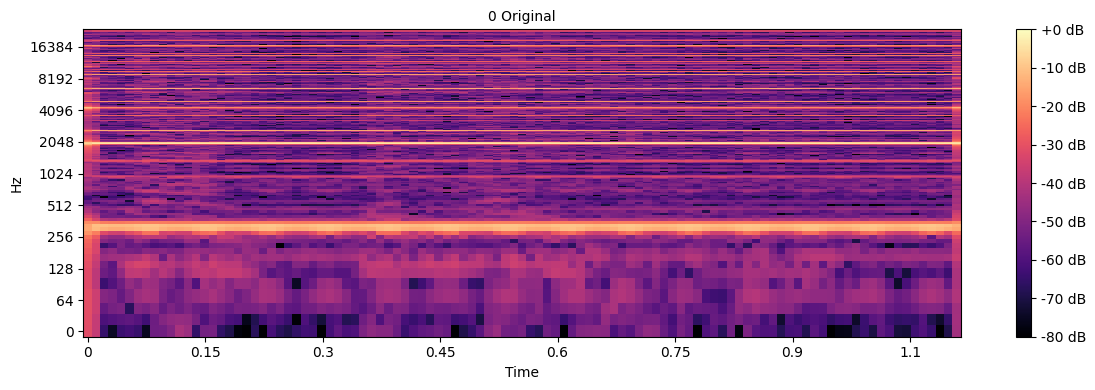

In [202]:
INPUT_FILE = "task5_1.wav"
audio, sr = librosa.load(INPUT_FILE, sr=None)
save_audio_step(audio, sr, "0 Original")

# STAGE 1: HARMONIC-PERCUSSIVE SOURCE SEPARATION (HPSS)

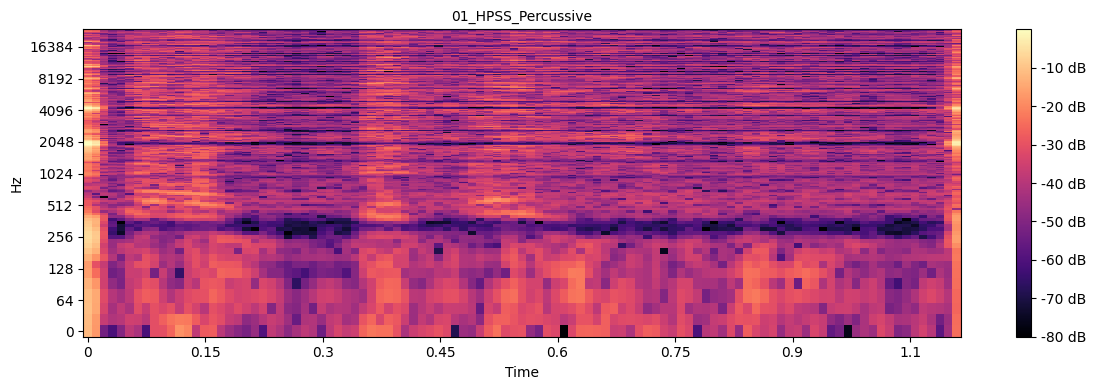

In [203]:
harmonic, percussive = librosa.effects.hpss(audio, margin=2.0)
y_work = percussive
save_audio_step(y_work, sr, "01_HPSS_Percussive")


# STAGE 2: AGGRESSIVE SPECTRAL GATING (Remove frequencies below threshold)

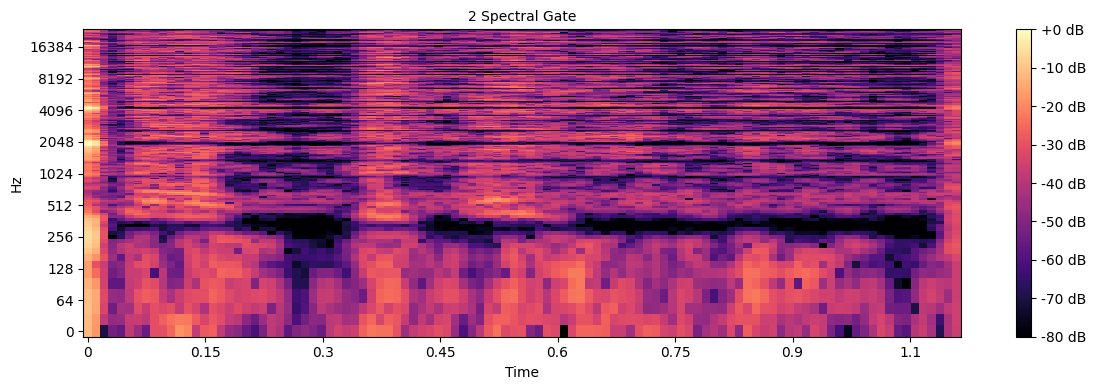

In [204]:


D = librosa.stft(y_work)
mag, phase = librosa.magphase(D)

# Use 50th percentile as threshold (aggressive)
threshold = np.percentile(mag, 50)
mag_gated = np.where(mag > threshold * 1.5, mag, mag * 0.1)
y_work = librosa.istft(mag_gated * phase)
save_audio_step(y_work, sr, "2 Spectral Gate")


# STAGE 3: BANDPASS FILTER (Speech-only zone: 300Hz - 4000Hz)

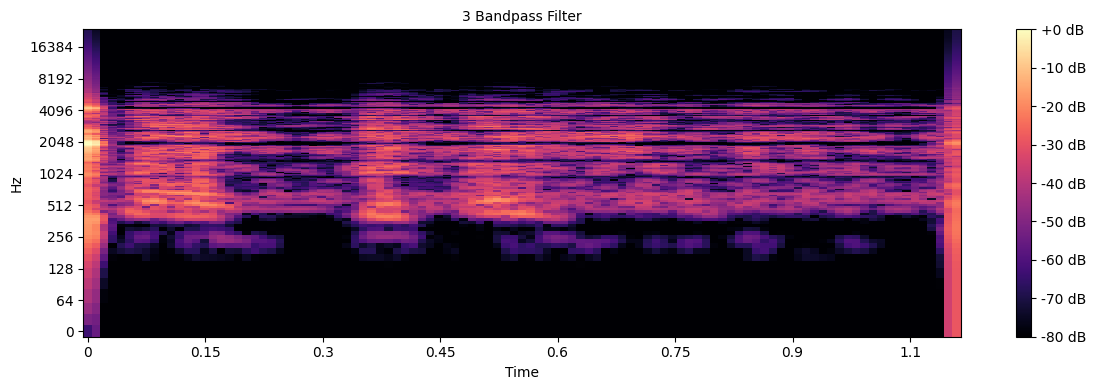

In [205]:
nyq = sr / 2
low = 300 / nyq
high = min(4000 / nyq, 0.99)
b, a = signal.butter(4, [low, high], btype='band')
y_work = signal.filtfilt(b, a, y_work)
save_audio_step(y_work, sr, "3 Bandpass Filter")


# STAGE 4: SPECTRAL SUBTRACTION (Advanced - subtract noise profile)

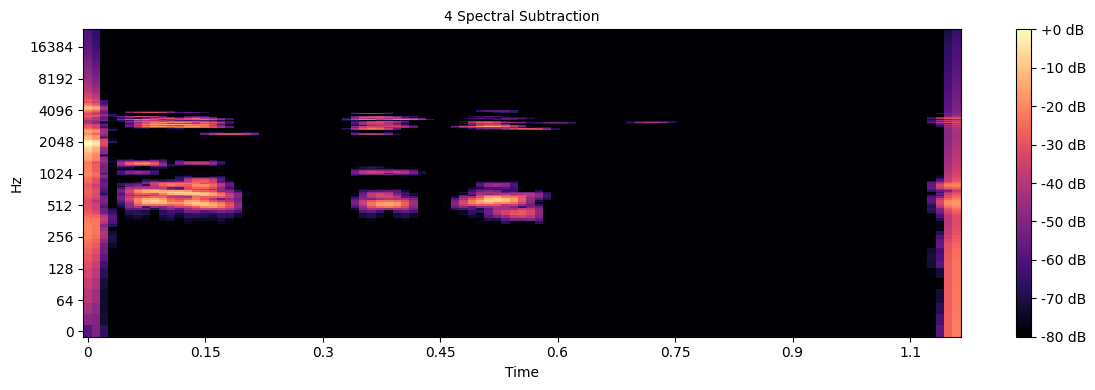

In [206]:
D = librosa.stft(y_work)
mag, phase = librosa.magphase(D)
noise_profile = np.mean(mag[:, :5], axis=1, keepdims=True)
mag_sub = np.maximum(0, mag - (2.0 * noise_profile))
y_work = librosa.istft(mag_sub * phase)
save_audio_step(y_work, sr, "4 Spectral Subtraction")


# STAGE 5: Trimming the actual speech

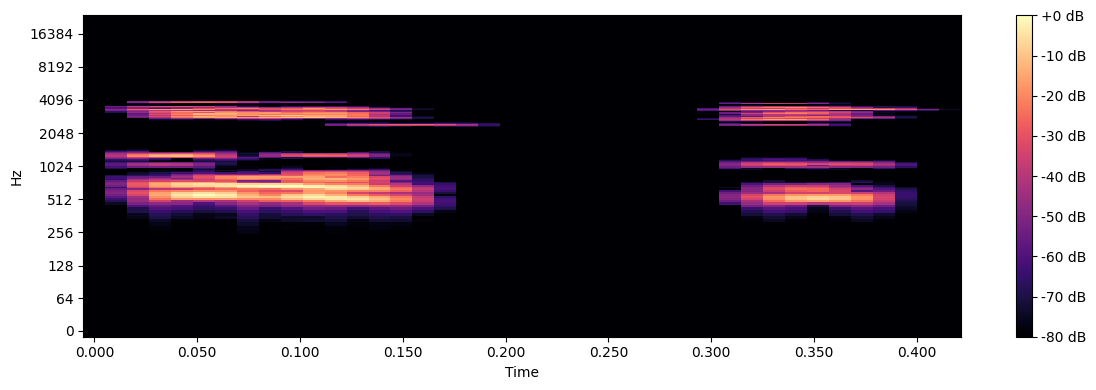

In [207]:
y_work = y_work[int(sr * 0.03):int(sr * 0.45)]
save_audio_step(y_work, sr, "")